# Power Rankings Export
End-to-end pipeline: loads trace → computes ratings → exports Substack HTML + Datawrapper CSV.

## 1. Config

In [3]:
import os, sys, pickle, sqlite3, re
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import arviz as az
from scipy.stats import poisson as scipy_poisson

# ── Font setup ───────────────────────────────────────────────
fm.fontManager.addfont('/Users/admin/Library/Fonts/Roboto-Regular.ttf')
fm.fontManager.addfont('/Users/admin/Library/Fonts/Roboto-Bold.ttf')
plt.rcParams['font.family'] = 'Roboto'

# ── Core config ───────────────────────────────────────────────
LEAGUE      = 'Premier_League'
SEASON      = '2025-2026'
SEASON_KEY  = '2025.11'
MODEL_VER   = 'manual_priors'
DB_PATH     = '/Users/admin/dev/algobetting/infra/data/db/fotmob.db'

FORM_END      = '2026-04-06'           # <-- update each week
FORM_START    = '2025-11-24'           # rolling window start
FORM_PREV_END = (
    datetime.strptime(FORM_END, '%Y-%m-%d') - timedelta(weeks=1)
).strftime('%Y-%m-%d')

BASELINE_HOME_PENS = 0.157 * 0.78
BASELINE_AWAY_PENS = 0.101 * 0.78

# ── Team logos (FPL CDN) ─────────────────────────────────────
team_logos = {
    'Arsenal':        'https://resources.premierleague.com/premierleague/badges/t3.png',
    'Aston Villa':    'https://resources.premierleague.com/premierleague/badges/t7.png',
    'Bournemouth':    'https://resources.premierleague.com/premierleague/badges/t91.png',
    'Brentford':      'https://resources.premierleague.com/premierleague/badges/t94.png',
    'Brighton':       'https://resources.premierleague.com/premierleague/badges/t36.png',
    'Burnley':        'https://resources.premierleague.com/premierleague/badges/t90.png',
    'Chelsea':        'https://resources.premierleague.com/premierleague/badges/t8.png',
    'Crystal Palace': 'https://resources.premierleague.com/premierleague/badges/t31.png',
    'Everton':        'https://resources.premierleague.com/premierleague/badges/t11.png',
    'Fulham':         'https://resources.premierleague.com/premierleague/badges/t54.png',
    'Leeds':          'https://resources.premierleague.com/premierleague/badges/t2.png',
    'Liverpool':      'https://r2.thesportsdb.com/images/media/team/badge/kfaher1737969724.png',
    'Man City':       'https://resources.premierleague.com/premierleague/badges/t43.png',
    'Man United':     'https://resources.premierleague.com/premierleague/badges/t1.png',
    'Newcastle':      'https://resources.premierleague.com/premierleague/badges/t4.png',
    'Nottm Forest':   'https://resources.premierleague.com/premierleague/badges/t17.png',
    'Tottenham':      'https://resources.premierleague.com/premierleague/badges/t6.png',
    'Sunderland':     'https://resources.premierleague.com/premierleague/badges/t56.png',
    'West Ham':       'https://resources.premierleague.com/premierleague/badges/t21.png',
    'Wolves':         'https://resources.premierleague.com/premierleague/badges/t39.png',
}

print(f"FORM_END:      {FORM_END}")
print(f"FORM_PREV_END: {FORM_PREV_END}")
print(f"FORM_START:    {FORM_START}")


FORM_END:      2026-04-06
FORM_PREV_END: 2026-03-30
FORM_START:    2025-11-24


## 2. Load Trace

In [4]:
NOTEBOOK_DIR = os.path.abspath('')
TRACE_DIR    = os.path.join(NOTEBOOK_DIR, 'model_traces', MODEL_VER)

trace_path = os.path.join(TRACE_DIR, f'trace_{LEAGUE}_{SEASON_KEY}.nc')
tm_path    = os.path.join(TRACE_DIR, f'team_mapping_{LEAGUE}_{SEASON_KEY}.pkl')

print(f"Loading trace: {trace_path}")
trace = az.from_netcdf(trace_path)

with open(tm_path, 'rb') as f:
    tm_raw = pickle.load(f)

team_mapping = {name: idx for idx, name in enumerate(tm_raw)} if isinstance(tm_raw, list) else tm_raw

print(f"Loaded {len(team_mapping)} teams.")
print(list(team_mapping.keys()))


Loading trace: /Users/admin/dev/algobetting/algo/models/team_strength/non_penalty_bayes/model_traces/manual_priors/trace_Premier_League_2025.11.nc
Loaded 20 teams.
['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton', 'Burnley', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Leeds', 'Liverpool', 'Man City', 'Man United', 'Newcastle', 'Nottm Forest', 'Sunderland', 'Tottenham', 'West Ham', 'Wolves']


## 3. Core Functions

In [5]:
# ─── predict_match ──────────────────────────────────────────────────────────

def predict_match(home_team, away_team, trace, team_mapping):
    home_idx = team_mapping[home_team]
    away_idx = team_mapping[away_team]
    att_str  = trace.posterior['att_str'].values.reshape(-1, len(team_mapping))
    def_str  = trace.posterior['def_str'].values.reshape(-1, len(team_mapping))
    baseline = trace.posterior['baseline'].values.flatten()
    home_adv = trace.posterior['home_adv'].values.flatten()

    home_open_play_lambda = np.exp(baseline + home_adv + att_str[:, home_idx] + def_str[:, away_idx])
    away_open_play_lambda = np.exp(baseline + att_str[:, away_idx] + def_str[:, home_idx])

    home_total_lambda = home_open_play_lambda + BASELINE_HOME_PENS
    away_total_lambda = away_open_play_lambda + BASELINE_AWAY_PENS

    home_goals_pred = np.random.poisson(home_total_lambda)
    away_goals_pred = np.random.poisson(away_total_lambda)

    return {
        'home_goals_expected': np.mean(home_total_lambda),
        'away_goals_expected': np.mean(away_total_lambda),
        'home_win_prob':  np.mean(home_goals_pred > away_goals_pred),
        'draw_prob':      np.mean(home_goals_pred == away_goals_pred),
        'away_win_prob':  np.mean(home_goals_pred < away_goals_pred),
    }


# ─── precompute_expected_goals ────────────────────────────────────────────────

def precompute_expected_goals(trace, team_mapping, df_actual):
    teams = list(team_mapping.keys())
    actual_results = {}
    expected_goals = {}

    played_matches = {}
    if df_actual is not None and 'is_actual' in df_actual.columns:
        for _, row in df_actual[df_actual['is_actual']].iterrows():
            key = (row['home_team'], row['away_team'])
            played_matches[key] = row

    total_fixtures = len(teams) * (len(teams) - 1)
    print(f"Pre-computing expected goals for up to {total_fixtures} fixtures...")

    for home_team in teams:
        for away_team in teams:
            if home_team == away_team:
                continue
            key = (home_team, away_team)
            if key in played_matches:
                row = played_matches[key]
                hg = int(row['home_goals']) if pd.notna(row['home_goals']) else None
                ag = int(row['away_goals']) if pd.notna(row['away_goals']) else None
                if hg is None or ag is None:
                    pred = predict_match(home_team, away_team, trace, team_mapping)
                    expected_goals[key] = (pred['home_goals_expected'], pred['away_goals_expected'])
                else:
                    pred = predict_match(home_team, away_team, trace, team_mapping)
                    actual_results[key] = (hg, ag, pred['home_goals_expected'], pred['away_goals_expected'])
            else:
                pred = predict_match(home_team, away_team, trace, team_mapping)
                expected_goals[key] = (pred['home_goals_expected'], pred['away_goals_expected'])

    print(f"  Actual fixtures: {len(actual_results)}")
    print(f"  To simulate:     {len(expected_goals)}")
    return actual_results, expected_goals


# ─── simulate_full_season_fast ────────────────────────────────────────────────

def _update_table(league_table, home_team, away_team, hg, ag, hxg, axg):
    ht = league_table[home_team]
    at = league_table[away_team]
    ht['played'] += 1;  at['played'] += 1
    ht['goals_for'] += hg;  ht['goals_against'] += ag
    at['goals_for'] += ag;  at['goals_against'] += hg
    ht['xg_for'] += hxg;   ht['xg_against'] += axg
    at['xg_for'] += axg;   at['xg_against'] += hxg
    if hg > ag:
        ht['wins'] += 1; ht['points'] += 3; at['losses'] += 1
    elif hg == ag:
        ht['draws'] += 1; ht['points'] += 1
        at['draws'] += 1; at['points'] += 1
    else:
        at['wins'] += 1; at['points'] += 3; ht['losses'] += 1


def simulate_full_season_fast(actual_results, expected_goals, teams):
    league_table = {team: {
        'played': 0, 'wins': 0, 'draws': 0, 'losses': 0,
        'goals_for': 0, 'goals_against': 0, 'goal_difference': 0,
        'xg_for': 0.0, 'xg_against': 0.0, 'xg_difference': 0.0,
        'points': 0
    } for team in teams}

    unplayed_keys = list(expected_goals.keys())
    if unplayed_keys:
        hxg_arr = np.array([expected_goals[k][0] for k in unplayed_keys])
        axg_arr = np.array([expected_goals[k][1] for k in unplayed_keys])
        home_goals_sim = np.random.poisson(hxg_arr)
        away_goals_sim = np.random.poisson(axg_arr)

    for (home_team, away_team), (hg, ag, hxg, axg) in actual_results.items():
        _update_table(league_table, home_team, away_team, hg, ag, hxg, axg)

    for i, (home_team, away_team) in enumerate(unplayed_keys):
        hxg, axg = expected_goals[(home_team, away_team)]
        _update_table(league_table, home_team, away_team,
                      home_goals_sim[i], away_goals_sim[i], hxg, axg)

    for team in teams:
        t = league_table[team]
        t['goal_difference'] = t['goals_for'] - t['goals_against']
        t['xg_difference']   = t['xg_for']    - t['xg_against']

    return league_table


# ─── run_multiple_seasons ────────────────────────────────────────────────────

def run_multiple_seasons(n_simulations, trace, team_mapping, df_actual):
    teams   = list(team_mapping.keys())
    n_teams = len(teams)

    actual_results, expected_goals = precompute_expected_goals(trace, team_mapping, df_actual)

    acc_points        = np.zeros(n_teams, dtype=np.float64)
    acc_wins          = np.zeros(n_teams, dtype=np.float64)
    acc_draws         = np.zeros(n_teams, dtype=np.float64)
    acc_losses        = np.zeros(n_teams, dtype=np.float64)
    acc_goals_for     = np.zeros(n_teams, dtype=np.float64)
    acc_goals_against = np.zeros(n_teams, dtype=np.float64)
    acc_xg_for        = np.zeros(n_teams, dtype=np.float64)
    acc_xg_against    = np.zeros(n_teams, dtype=np.float64)
    acc_positions     = np.zeros(n_teams, dtype=np.float64)
    title_counts      = np.zeros(n_teams, dtype=np.int32)
    top5_counts       = np.zeros(n_teams, dtype=np.int32)
    relegation_counts = np.zeros(n_teams, dtype=np.int32)
    pos_freq          = np.zeros((n_teams, n_teams), dtype=np.int32)
    acc_pts_sq        = np.zeros(n_teams, dtype=np.float64)  # for std dev

    print(f"Running {n_simulations:,} simulations...")

    for sim in range(n_simulations):
        if sim % 1000 == 0 and sim > 0:
            print(f"  {sim:,} / {n_simulations:,} done...")

        league_table = simulate_full_season_fast(actual_results, expected_goals, teams)

        pts   = np.array([league_table[t]['points']          for t in teams])
        gd    = np.array([league_table[t]['goal_difference']  for t in teams])
        gf    = np.array([league_table[t]['goals_for']        for t in teams])
        order = np.lexsort((gf, gd, pts))[::-1]

        positions = np.empty(n_teams, dtype=np.int32)
        positions[order] = np.arange(1, n_teams + 1)

        acc_points        += pts
        acc_pts_sq        += pts ** 2
        acc_wins          += [league_table[t]['wins']          for t in teams]
        acc_draws         += [league_table[t]['draws']         for t in teams]
        acc_losses        += [league_table[t]['losses']        for t in teams]
        acc_goals_for     += [league_table[t]['goals_for']     for t in teams]
        acc_goals_against += [league_table[t]['goals_against'] for t in teams]
        acc_xg_for        += [league_table[t]['xg_for']        for t in teams]
        acc_xg_against    += [league_table[t]['xg_against']    for t in teams]
        acc_positions     += positions
        title_counts      += (positions == 1)
        top5_counts        += (positions <= 5)
        relegation_counts  += (positions >= 18)
        pos_freq[np.arange(n_teams), positions - 1] += 1

    avg_df = pd.DataFrame({
        'team':              teams,
        'avg_points':        acc_points        / n_simulations,
        'avg_wins':          acc_wins          / n_simulations,
        'avg_draws':         acc_draws         / n_simulations,
        'avg_losses':        acc_losses        / n_simulations,
        'avg_goals_for':     acc_goals_for     / n_simulations,
        'avg_goals_against': acc_goals_against / n_simulations,
        'avg_xg_for':        acc_xg_for        / n_simulations,
        'avg_xg_against':    acc_xg_against    / n_simulations,
        'avg_position':      acc_positions     / n_simulations,
        'title_pct':         np.round(title_counts      / n_simulations * 100, 1),
        'top5_pct':          np.round(top5_counts        / n_simulations * 100, 1),
        'relegation_pct':    np.round(relegation_counts  / n_simulations * 100, 1),
        'pts_low':           acc_points / n_simulations - 1.28 * np.sqrt(np.maximum(acc_pts_sq / n_simulations - (acc_points / n_simulations) ** 2, 0)),
        'pts_high':          acc_points / n_simulations + 1.28 * np.sqrt(np.maximum(acc_pts_sq / n_simulations - (acc_points / n_simulations) ** 2, 0)),
    })
    avg_df['avg_goal_difference'] = avg_df['avg_goals_for'] - avg_df['avg_goals_against']
    avg_df['avg_xg_difference']   = avg_df['avg_xg_for']    - avg_df['avg_xg_against']
    avg_df = avg_df.sort_values(
        ['avg_points', 'avg_goal_difference', 'avg_goals_for'],
        ascending=[False, False, False]
    ).reset_index(drop=True)
    avg_df.index = avg_df.index + 1

    position_counts = {team: list(pos_freq[i]) for i, team in enumerate(teams)}
    return avg_df, position_counts


# ─── load_actual_results ─────────────────────────────────────────────────────

def load_actual_results(db_path: str, league: str, season: str) -> pd.DataFrame:
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query("""
        SELECT
            match_date,
            home.team_name  AS home_team,
            fmd.home_goals,
            away.team_name  AS away_team,
            fmd.away_goals
        FROM matches fmd
            JOIN team_id_mapping home ON home.team_id = fmd.home_team
            JOIN team_id_mapping away ON away.team_id = fmd.away_team
        WHERE
            fmd.league_id = ?
            AND fmd.season  = ?
    """, conn, params=[league, season])
    conn.close()
    df['is_actual'] = True
    return df


# ─── form_net_rating ─────────────────────────────────────────────────────────

def form_net_rating(weighted_df):
    BASELINE_HOME_PENS = 0.157 * 0.78
    BASELINE_AWAY_PENS = 0.101 * 0.78
    me = weighted_df.groupby('match_id').apply(lambda x: pd.Series({
        'exp_home_goals': (x['home_goals'] * x['weight']).sum() / x['weight'].sum(),
        'exp_away_goals': (x['away_goals'] * x['weight']).sum() / x['weight'].sum(),
        'match_weight':    x['weight'].sum()
    })).reset_index()
    mm = weighted_df[['match_id', 'home_team', 'away_team']].drop_duplicates()
    me = me.merge(mm, on='match_id')

    home_s = me.groupby('home_team').apply(lambda x: pd.Series({
        'gf': (x['exp_home_goals'] * x['match_weight']).sum(),
        'ga': (x['exp_away_goals'] * x['match_weight']).sum(),
        'w':   x['match_weight'].sum()
    }))
    away_s = me.groupby('away_team').apply(lambda x: pd.Series({
        'gf': (x['exp_away_goals'] * x['match_weight']).sum(),
        'ga': (x['exp_home_goals'] * x['match_weight']).sum(),
        'w':   x['match_weight'].sum()
    }))

    pen_avg = (BASELINE_HOME_PENS + BASELINE_AWAY_PENS) / 2
    ts = pd.DataFrame(index=home_s.index)
    ts['gf_avg']     = (home_s['gf'] + away_s['gf']) / (home_s['w'] + away_s['w']) + pen_avg
    ts['ga_avg']     = (home_s['ga'] + away_s['ga']) / (home_s['w'] + away_s['w']) + pen_avg
    ts['net_rating'] = ts['gf_avg'] - ts['ga_avg']
    return ts.sort_values('net_rating', ascending=False)


# ─── get_actual_standings ─────────────────────────────────────────────────────

def get_actual_standings(actual_results_dict, teams):
    """Return a DataFrame with pts, gd, gf, position for each team."""
    s = {t: {'pts': 0, 'w': 0, 'd': 0, 'l': 0, 'gf': 0, 'ga': 0} for t in teams}
    for (ht, at), (hg, ag, *_) in actual_results_dict.items():
        s[ht]['gf'] += hg; s[ht]['ga'] += ag
        s[at]['gf'] += ag; s[at]['ga'] += hg
        if hg > ag:
            s[ht]['pts'] += 3; s[ht]['w'] += 1; s[at]['l'] += 1
        elif hg == ag:
            s[ht]['pts'] += 1; s[ht]['d'] += 1; s[at]['pts'] += 1; s[at]['d'] += 1
        else:
            s[at]['pts'] += 3; s[at]['w'] += 1; s[ht]['l'] += 1

    df = pd.DataFrame(s).T.reset_index().rename(columns={'index': 'team'})
    df['gd'] = df['gf'] - df['ga']
    df = df.sort_values(['pts', 'gd', 'gf'], ascending=False).reset_index(drop=True)
    df['table_pos'] = df.index + 1
    return df


# ─── get_last_result ─────────────────────────────────────────────────────────

def get_last_result(df_act, team):
    involved = df_act[
        (df_act['home_team'] == team) | (df_act['away_team'] == team)
    ].copy()
    if involved.empty:
        return 'No result'
    if 'match_date' in involved.columns:
        involved = involved.sort_values('match_date')
    last     = involved.iloc[-1]
    is_home  = last['home_team'] == team
    hg, ag   = int(last['home_goals']), int(last['away_goals'])
    opponent = last['away_team'] if is_home else last['home_team']
    venue    = 'Home' if is_home else 'Away'
    tg = hg if is_home else ag
    og = ag if is_home else hg
    outcome = 'win' if tg > og else ('draw' if tg == og else 'loss')
    return f'{hg}-{ag} {venue} {outcome} vs {opponent}'


# ─── get_form_string ──────────────────────────────────────────────────────────

def get_form_string(df_act, team, n=5):
    involved = df_act[
        (df_act['home_team'] == team) | (df_act['away_team'] == team)
    ].copy()
    if involved.empty:
        return ''
    if 'match_date' in involved.columns:
        involved = involved.sort_values('match_date')
    results = []
    for _, row in involved.iterrows():
        is_home = row['home_team'] == team
        hg, ag  = int(row['home_goals']), int(row['away_goals'])
        tg = hg if is_home else ag
        og = ag if is_home else hg
        results.append('W' if tg > og else ('D' if tg == og else 'L'))
    return ''.join(results[-n:])


# ─── rank_arrow ───────────────────────────────────────────────────────────────

def rank_arrow(current_rank, prev_rank):
    if prev_rank is None:
        return '●'
    if current_rank < prev_rank:
        return '▲'
    elif current_rank > prev_rank:
        return '▼'
    else:
        return '▬'


print("All helper functions defined.")


All helper functions defined.


## 4. Build ratings_df

Bayesian avg-vs-all-opponents rating (Jensen's inequality corrected).

In [6]:
baseline_samples  = trace.posterior['baseline'].values.flatten()
home_adv_samples  = trace.posterior['home_adv'].values.flatten()
all_teams = list(team_mapping.keys())

team_stats = {team: {'goals_for': 0, 'goals_against': 0, 'matches': 0} for team in all_teams}

for home_team in all_teams:
    home_idx = team_mapping[home_team]
    home_att_samples = trace.posterior['att_str'].sel(att_str_dim_0=home_idx).values.flatten()
    home_def_samples = trace.posterior['def_str'].sel(def_str_dim_0=home_idx).values.flatten()

    for away_team in all_teams:
        if home_team == away_team:
            continue
        away_idx = team_mapping[away_team]
        away_att_samples = trace.posterior['att_str'].sel(att_str_dim_0=away_idx).values.flatten()
        away_def_samples = trace.posterior['def_str'].sel(def_str_dim_0=away_idx).values.flatten()

        home_lambda = np.exp(baseline_samples + home_adv_samples + home_att_samples + away_def_samples)
        away_lambda = np.exp(baseline_samples + away_att_samples + home_def_samples)

        home_goals = np.mean(home_lambda) + BASELINE_HOME_PENS
        away_goals = np.mean(away_lambda) + BASELINE_AWAY_PENS

        team_stats[home_team]['goals_for']     += home_goals
        team_stats[home_team]['goals_against'] += away_goals
        team_stats[home_team]['matches']       += 1
        team_stats[away_team]['goals_for']     += away_goals
        team_stats[away_team]['goals_against'] += home_goals
        team_stats[away_team]['matches']       += 1

team_ratings = []
for team in all_teams:
    gf = team_stats[team]['goals_for']     / team_stats[team]['matches']
    ga = team_stats[team]['goals_against'] / team_stats[team]['matches']
    team_ratings.append({'team': team, 'goals_for': gf, 'goals_against': ga, 'goal_diff': gf - ga})

ratings_df = (pd.DataFrame(team_ratings)
              .sort_values('goal_diff', ascending=False)
              .reset_index(drop=True))
print(ratings_df.to_string(index=False))

# P(above avg): fraction of posterior samples where team's net quality > 0.
# At neutral venue vs average opponent (att_j=0, def_j=0):
#   GD > 0  iff  exp(baseline + att_i) > exp(baseline + def_i)  iff  att_i > def_i
att_samples_all = trace.posterior['att_str'].values.reshape(-1, len(team_mapping))
def_samples_all = trace.posterior['def_str'].values.reshape(-1, len(team_mapping))

p_above = {}
for team, idx in team_mapping.items():
    net = att_samples_all[:, idx] - def_samples_all[:, idx]
    p_above[team] = round(float((net > 0).mean()) * 100, 1)

ratings_df['P(above avg)'] = ratings_df['team'].map(p_above)

# ── Datawrapper export — BEST Model Ratings ──────────────────────────────────
dw_ratings = ratings_df[['team', 'goals_for', 'goals_against', 'goal_diff', 'P(above avg)']].copy()
dw_ratings.columns = ['Team', 'GF', 'GA', 'GD', 'P(above avg) %']
dw_ratings['GF'] = dw_ratings['GF'].round(2)
dw_ratings['GA'] = dw_ratings['GA'].round(2)
dw_ratings['GD'] = dw_ratings['GD'].round(2)
dw_ratings.insert(0, 'Logo', dw_ratings['Team'].map(lambda t: f'![]({team_logos.get(t, "")})'))

print("--- COPY EVERYTHING BELOW THIS LINE (BEST Model Ratings) ---")
print(dw_ratings.to_csv(index=False))


          team  goals_for  goals_against  goal_diff
       Arsenal   1.736285       0.861901   0.874385
      Man City   1.774287       1.141464   0.632822
     Liverpool   1.692199       1.218706   0.473494
       Chelsea   1.678360       1.327497   0.350864
    Man United   1.583043       1.293305   0.289739
      Brighton   1.413012       1.246349   0.166663
     Brentford   1.438822       1.280812   0.158010
     Newcastle   1.441870       1.320346   0.121524
   Aston Villa   1.386789       1.362317   0.024471
Crystal Palace   1.287334       1.310993  -0.023659
   Bournemouth   1.459261       1.484252  -0.024992
         Leeds   1.320305       1.372008  -0.051704
        Fulham   1.290964       1.404948  -0.113984
       Everton   1.220214       1.365261  -0.145047
  Nottm Forest   1.203942       1.388897  -0.184955
     Tottenham   1.279399       1.550679  -0.271280
      West Ham   1.182232       1.586504  -0.404272
    Sunderland   0.972615       1.391051  -0.418436
        Wolv

## 5. Load Actual Data

In [7]:
df_actual = load_actual_results(DB_PATH, LEAGUE, SEASON)
print(f"Actual matches loaded: {len(df_actual)}")

actual_results, expected_goals = precompute_expected_goals(trace, team_mapping, df_actual)


Actual matches loaded: 309
Pre-computing expected goals for up to 380 fixtures...
  Actual fixtures: 309
  To simulate:     71


## 6. Season Projections

In [8]:
n_sims = 10000
avg_table, position_freq = run_multiple_seasons(n_sims, trace, team_mapping, df_actual)

# Build Datawrapper projections CSV
export_df = avg_table.sort_values(['avg_points', 'avg_goal_difference'], ascending=False).copy()
export_df['Pts (Low)']  = export_df['pts_low'].round(1)
export_df['Pts (High)'] = export_df['pts_high'].round(1)
final_export = export_df[[
    'team', 'avg_points', 'Pts (Low)', 'Pts (High)', 'avg_goals_for', 'avg_goals_against', 'avg_goal_difference',
    'title_pct', 'top5_pct', 'relegation_pct'
]].copy()
final_export.columns = ['Team', 'Points', 'Pts (Low)', 'Pts (High)', 'GF', 'GA', 'GD', 'Title %', 'Top 5 %', 'Relegation %']
final_export.insert(0, 'Logo', final_export['Team'].map(lambda t: f'![]({team_logos.get(t, "")})'))

print("--- COPY EVERYTHING BELOW THIS LINE (Season Projections) ---")
print(final_export.to_csv(index=False))


Pre-computing expected goals for up to 380 fixtures...
  Actual fixtures: 309
  To simulate:     71
Running 10,000 simulations...
  1,000 / 10,000 done...
  2,000 / 10,000 done...
  3,000 / 10,000 done...
  4,000 / 10,000 done...
  5,000 / 10,000 done...
  6,000 / 10,000 done...
  7,000 / 10,000 done...
  8,000 / 10,000 done...
  9,000 / 10,000 done...
--- COPY EVERYTHING BELOW THIS LINE (Season Projections) ---
Logo,Team,Points,Pts (Low),Pts (High),GF,GA,GD,Title %,Top 5 %,Relegation %
![](https://resources.premierleague.com/premierleague/badges/t3.png),Arsenal,84.1155,80.1,88.1,73.8139,27.9391,45.87480000000001,96.1,100.0,0.0
![](https://resources.premierleague.com/premierleague/badges/t43.png),Man City,74.8716,70.2,79.5,73.8341,37.4611,36.373000000000005,3.9,100.0,0.0
![](https://resources.premierleague.com/premierleague/badges/t1.png),Man United,65.8199,61.4,70.2,66.8068,52.076,14.730799999999995,0.0,94.0,0.0
![](https://resources.premierleague.com/premierleague/badges/t7.png),Asto

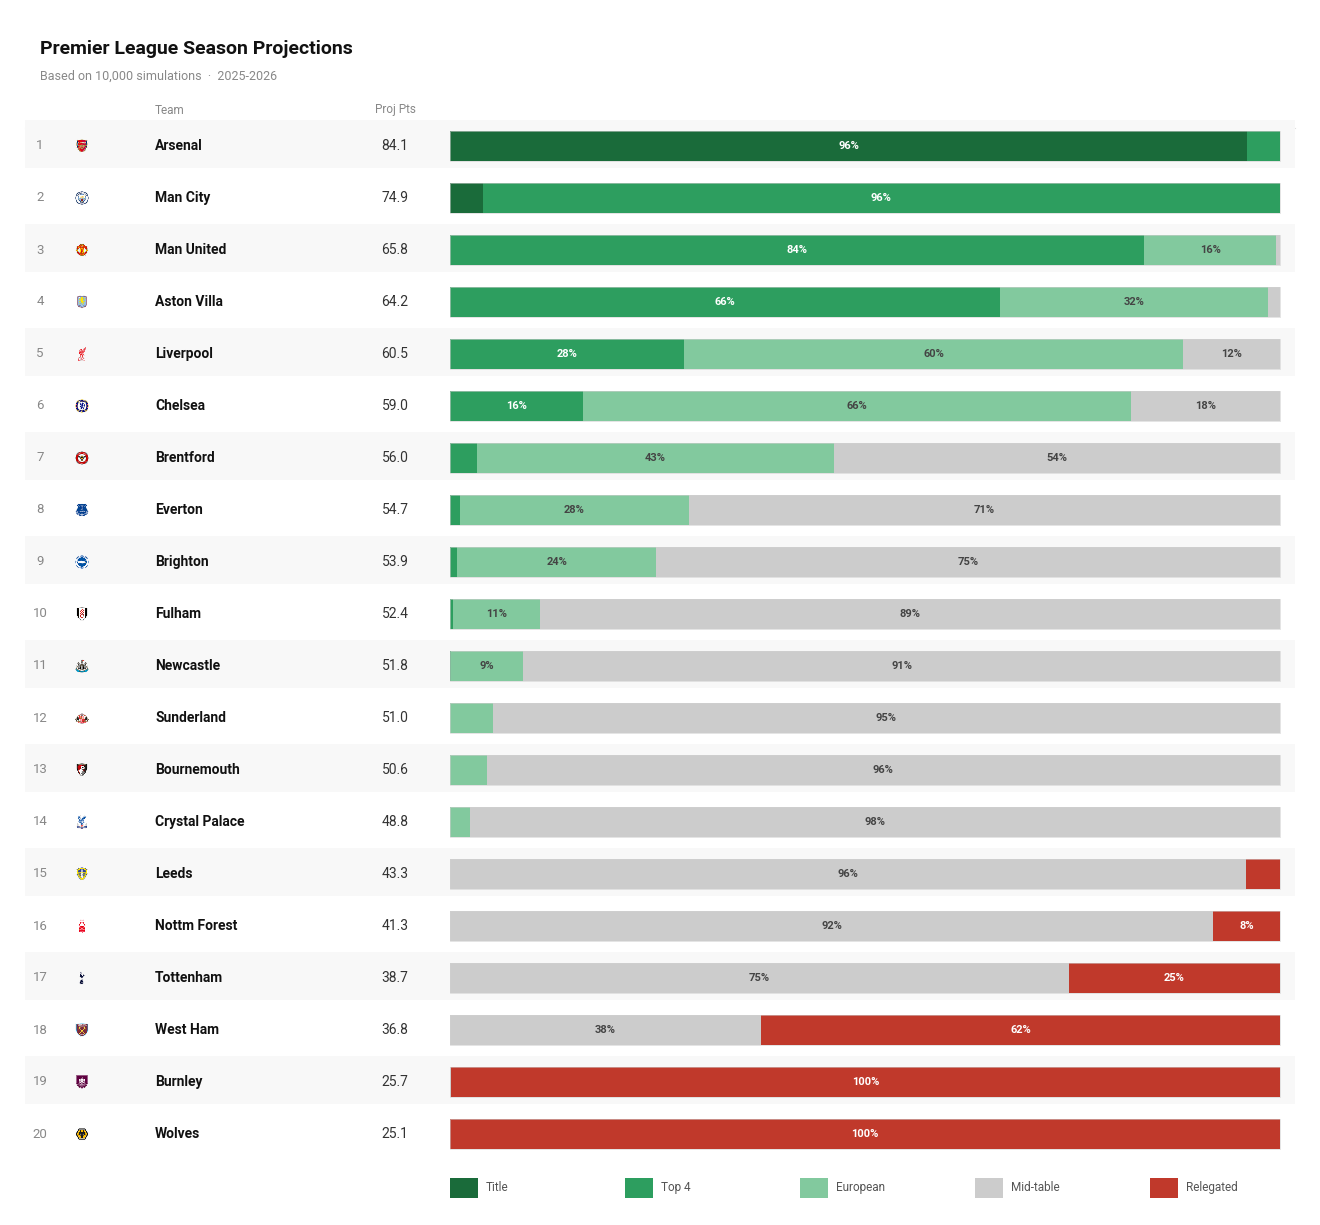

Saved premier_league_projections.png


In [9]:
# =============================================================================
# 538-style Season Projections Chart
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
import numpy as np
import requests
from PIL import Image
from io import BytesIO
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

fm.fontManager.addfont('/Users/admin/Library/Fonts/Roboto-Regular.ttf')
fm.fontManager.addfont('/Users/admin/Library/Fonts/Roboto-Bold.ttf')
plt.rcParams['font.family'] = 'Roboto'

# ── Zone definitions ──────────────────────────────────────────────────────────
ZONES = [
    ('Title',     [1],                  '#1a6b3a'),
    ('Top 4',     [2, 3, 4],            '#2d9e5f'),
    ('European',  [5, 6, 7],            '#82c99e'),
    ('Mid-table', list(range(8, 18)),   '#cccccc'),
    ('Relegated', [18, 19, 20],         '#c0392b'),
]

def zone_probs(team):
    counts = position_freq[team]
    return [(name, sum(counts[p-1] for p in positions) / n_sims, color)
            for name, positions, color in ZONES]

def fetch_badge(url, size=48):
    try:
        r = requests.get(url, timeout=4)
        img = Image.open(BytesIO(r.content)).convert('RGBA')
        img.thumbnail((size, size), Image.LANCZOS)
        return img
    except Exception:
        return None

# ── Pre-fetch badges ──────────────────────────────────────────────────────────
badge_cache = {}
for team, url in team_logos.items():
    if url and url not in badge_cache:
        badge_cache[url] = fetch_badge(url)

# ── Layout constants (all in inches, figure coords) ───────────────────────────
teams_sorted = avg_table.sort_values('avg_position')['team'].tolist()
n_teams      = len(teams_sorted)

ROW_H    = 0.52
PAD_TOP  = 1.1
PAD_BOT  = 0.55
FIG_W    = 13.0
FIG_H    = n_teams * ROW_H + PAD_TOP + PAD_BOT

X_RANK   = 0.30
X_BADGE  = 0.72
X_NAME   = 1.45
X_PTS    = 3.85
X_BAR_L  = 4.40
X_BAR_R  = FIG_W - 0.30
BAR_W    = X_BAR_R - X_BAR_L
BAR_FRAC = 0.58   # bar height as fraction of row height

fig = plt.figure(figsize=(FIG_W, FIG_H))
fig.patch.set_facecolor('white')
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, FIG_W)
ax.set_ylim(0, FIG_H)
ax.axis('off')

# ── Title ─────────────────────────────────────────────────────────────────────
ax.text(X_RANK, FIG_H - 0.30, 'Premier League Season Projections',
        fontsize=14, fontweight='bold', color='#111', va='top', ha='left')
ax.text(X_RANK, FIG_H - 0.60,
        f'Based on {n_sims:,} simulations  ·  {SEASON}',
        fontsize=9, color='#888', va='top', ha='left')

# ── Column headers ────────────────────────────────────────────────────────────
header_y = FIG_H - PAD_TOP + 0.10
ax.text(X_NAME, header_y, 'Team',     fontsize=8.5, color='#888', va='center', ha='left')
ax.text(X_PTS,  header_y, 'Proj Pts', fontsize=8.5, color='#888', va='center', ha='center')
ax.plot([0.15, FIG_W - 0.15], [header_y - 0.18, header_y - 0.18],
        color='#e0e0e0', lw=0.8, zorder=0)

# ── Rows ──────────────────────────────────────────────────────────────────────
for i, team in enumerate(teams_sorted):
    row_top = FIG_H - PAD_TOP - i * ROW_H
    row_mid = row_top - ROW_H / 2
    bar_h   = ROW_H * BAR_FRAC
    bar_y   = row_mid - bar_h / 2

    # Alternating background
    bg = mpatches.Rectangle(
        (0.15, row_top - ROW_H + 0.04), FIG_W - 0.30, ROW_H - 0.04,
        facecolor='#f8f8f8' if i % 2 == 0 else 'white',
        edgecolor='none', zorder=0)
    ax.add_patch(bg)

    # Rank
    ax.text(X_RANK, row_mid, str(i + 1),
            fontsize=9.5, va='center', ha='center', color='#888')

    # Badge
    url = team_logos.get(team)
    if url and badge_cache.get(url) is not None:
        im = OffsetImage(badge_cache[url], zoom=0.20)
        ab = AnnotationBbox(im, (X_BADGE, row_mid), frameon=False, zorder=2)
        ax.add_artist(ab)

    # Team name
    ax.text(X_NAME, row_mid, team,
            fontsize=10, va='center', ha='left', color='#111', fontweight='bold')

    # Projected points
    pts = avg_table[avg_table['team'] == team]['avg_points'].values[0]
    ax.text(X_PTS, row_mid, f'{pts:.1f}',
            fontsize=10, va='center', ha='center', color='#333')

    # Stacked probability bar
    x_cursor = X_BAR_L
    for name, prob, color in zone_probs(team):
        seg_w = prob * BAR_W
        if seg_w < 0.002:
            continue
        rect = mpatches.Rectangle(
            (x_cursor, bar_y), seg_w, bar_h,
            facecolor=color, edgecolor='none', zorder=1)
        ax.add_patch(rect)
        # Label segments wide enough to fit text
        if prob >= 0.07:
            text_color = 'white' if color not in ('#cccccc', '#82c99e') else '#444'
            ax.text(x_cursor + seg_w / 2, row_mid,
                    f'{prob*100:.0f}%',
                    fontsize=8, va='center', ha='center',
                    color=text_color, fontweight='bold', zorder=3)
        x_cursor += seg_w

    # Bar border
    ax.add_patch(mpatches.Rectangle(
        (X_BAR_L, bar_y), BAR_W, bar_h,
        facecolor='none', edgecolor='#d0d0d0', lw=0.4, zorder=4))

# ── Legend ────────────────────────────────────────────────────────────────────
leg_x = X_BAR_L
leg_y = PAD_BOT * 0.50
for name, positions, color in ZONES:
    ax.add_patch(mpatches.Rectangle(
        (leg_x, leg_y - 0.10), 0.28, 0.20,
        facecolor=color, edgecolor='none'))
    ax.text(leg_x + 0.36, leg_y, name, fontsize=8.5, va='center', color='#555')
    leg_x += 1.75

plt.savefig('premier_league_projections.png', dpi=160,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved premier_league_projections.png")


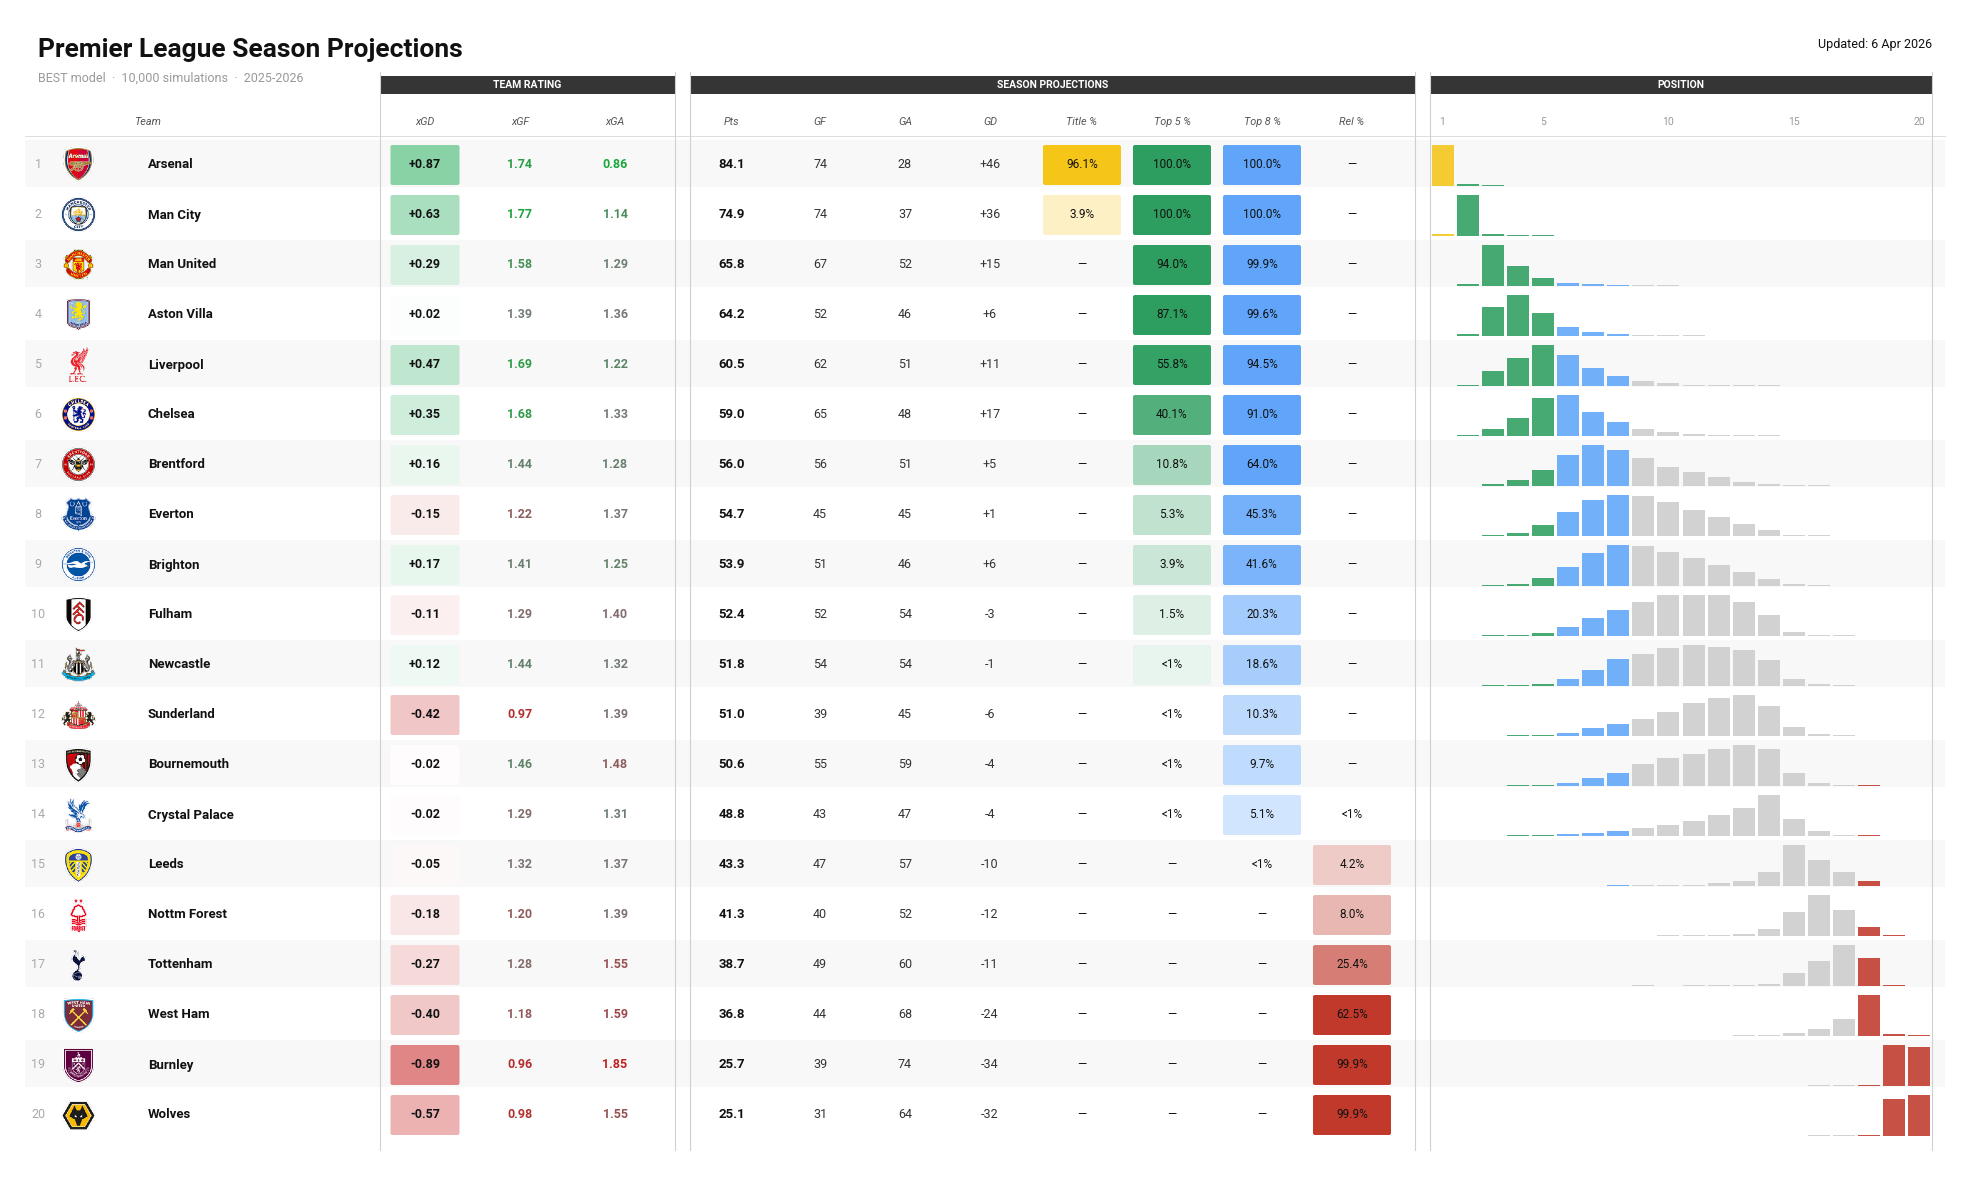

Saved premier_league_combined_table.png


In [10]:
# =============================================================================
# Combined 538-style Table: Ratings + Projections + Position Distribution
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
import matplotlib.colors as mcolors
import numpy as np
import requests
from PIL import Image
from io import BytesIO
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from datetime import date

fm.fontManager.addfont('/Users/admin/Library/Fonts/Roboto-Regular.ttf')
fm.fontManager.addfont('/Users/admin/Library/Fonts/Roboto-Bold.ttf')
plt.rcParams['font.family'] = 'Roboto'

# ── Zone definitions ──────────────────────────────────────────────────────────
ZONES = [
    ('Title',     [1],                '#F5C518'),
    ('Top 5',     [2, 3, 4, 5],       '#2d9e5f'),
    ('Top 8',     [6, 7, 8],          '#60A5FA'),
    ('Mid-table', list(range(9, 18)), '#cccccc'),
    ('Relegated', [18, 19, 20],       '#c0392b'),
]

# Zone color lookup by position
_pos_color = {}
for _name, _positions, _color in ZONES:
    for _p in _positions:
        _pos_color[_p] = _color

def get_zone_prob(team, zone_positions):
    counts = position_freq[team]
    return sum(counts[p-1] for p in zone_positions) / n_sims

# ── Color helpers ─────────────────────────────────────────────────────────────
def xgd_color(val, vmin=-1.5, vmax=1.5):
    """Cell background: green for positive xGD, red for negative."""
    norm = max(0, min(1, (val - vmin) / (vmax - vmin)))
    if norm >= 0.5:
        t = (norm - 0.5) * 2
        return mcolors.to_hex((1 - t * 0.8, 1 - t * 0.3, 1 - t * 0.6))
    else:
        t = (0.5 - norm) * 2
        return mcolors.to_hex((1 - t * 0.2, 1 - t * 0.8, 1 - t * 0.8))

def _stat_font_color(val, avg, spread, good_direction='high'):
    """
    Symmetric font colour: good = green, average = grey, bad = red.
    good_direction='high'  → high values are green (xGF, xGD)
    good_direction='low'   → low values are green (xGA)
    """
    t = (val - avg) / spread           # negative = below avg, positive = above avg
    if good_direction == 'low':
        t = -t                          # flip so low = positive = good
    t = max(-1, min(1, t))
    if t >= 0:                          # good side → green
        r = 0.47 - t * 0.38
        g = 0.47 + t * 0.18
        b = 0.47 - t * 0.25
    else:                               # bad side → red
        s = -t
        r = 0.47 + s * 0.28
        g = 0.47 - s * 0.35
        b = 0.47 - s * 0.35
    return mcolors.to_hex((max(0,r), max(0,g), max(0,b)))

def xgf_font_color(val, avg=1.35, spread=0.45):
    return _stat_font_color(val, avg, spread, good_direction='high')

def xga_font_color(val, avg=1.35, spread=0.45):
    return _stat_font_color(val, avg, spread, good_direction='low')

def zone_cell_color(zone_color_hex, intensity):
    """Tint a zone colour towards white based on intensity (0–1)."""
    r, g, b = mcolors.to_rgb(zone_color_hex)
    t = intensity ** 0.5            # sqrt so low values still show a tint
    white = 1.0
    return mcolors.to_hex((
        white + (r - white) * t,
        white + (g - white) * t,
        white + (b - white) * t,
    ))

_SAVE_DPI       = 160   # must match plt.savefig dpi
BADGE_DISPLAY_PX = 56   # desired badge size in output pixels (tune this for size)

def fetch_badge(url):
    """
    Downscale to BADGE_DISPLAY_PX using LANCZOS so PIL does the quality work,
    then display with zoom = 72/_SAVE_DPI so every image pixel = 1 output pixel.
    """
    try:
        r = requests.get(url, timeout=4)
        img = Image.open(BytesIO(r.content)).convert('RGBA')
        scale = BADGE_DISPLAY_PX / max(img.width, img.height)
        new_w = max(1, round(img.width  * scale))
        new_h = max(1, round(img.height * scale))
        img = img.resize((new_w, new_h), Image.LANCZOS)
        square = Image.new('RGBA', (BADGE_DISPLAY_PX, BADGE_DISPLAY_PX), (0, 0, 0, 0))
        square.paste(img, ((BADGE_DISPLAY_PX - new_w) // 2, (BADGE_DISPLAY_PX - new_h) // 2))
        return square
    except Exception:
        return None

# ── Pre-fetch badges ──────────────────────────────────────────────────────────
badge_cache = {}
for team, url in team_logos.items():
    if url and url not in badge_cache:
        badge_cache[url] = fetch_badge(url)  # loads full-res, matplotlib downsamples

# ── Data prep ─────────────────────────────────────────────────────────────────
teams_sorted   = avg_table.sort_values('avg_position')['team'].tolist()
n_teams        = len(teams_sorted)
ratings_lookup = ratings_df.set_index('team')

# Compute top8_pct for each team from position_freq
for _, row in avg_table.iterrows():
    pass  # avg_table already has title_pct, top5_pct, relegation_pct
# Add top8_pct if missing
if 'top8_pct' not in avg_table.columns:
    avg_table['top8_pct'] = avg_table['team'].apply(
        lambda t: round(get_zone_prob(t, [1,2,3,4,5,6,7,8]) * 100, 1)
    )

# ── Layout (inches) ───────────────────────────────────────────────────────────
ROW_H   = 0.50
PAD_TOP = 1.30
PAD_BOT = 0.35
FIG_W   = 19.5
FIG_H   = n_teams * ROW_H + PAD_TOP + PAD_BOT

X_RANK  = 0.28
X_BADGE = 0.68
X_NAME  = 1.38

# Ratings section
SEC1_L  = 3.70
X_XGD   = 4.15
X_XGF   = 5.10
X_XGA   = 6.05
SEC1_R  = 6.65

# Projections section  (pts + sim goals + 4 pct cols)
SEC2_L  = 6.80
X_PTS   = 7.22
X_PGFD  = 8.10    # proj GF
X_PGAD  = 8.95    # proj GA
X_PGDD  = 9.80    # proj GD
X_TITLE = 10.72
X_TOP5  = 11.62
X_TOP8  = 12.52
X_REL   = 13.42
SEC2_R  = 14.05

# Position distribution
X_BAR_L = 14.20
X_BAR_R = FIG_W - 0.28
BAR_W   = X_BAR_R - X_BAR_L

fig = plt.figure(figsize=(FIG_W, FIG_H))
fig.patch.set_facecolor('white')
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, FIG_W)
ax.set_ylim(0, FIG_H)
ax.axis('off')

# ── Title ─────────────────────────────────────────────────────────────────────
ax.text(X_RANK, FIG_H - 0.28, 'Premier League Season Projections',
        fontsize=19, fontweight='bold', color='#111', va='top', ha='left')
ax.text(X_RANK, FIG_H - 0.62,
        f'BEST model  ·  {n_sims:,} simulations  ·  {SEASON}',
        fontsize=9, color='#999', va='top', ha='left')
ax.text(FIG_W - 0.28, FIG_H - 0.28,f'Updated: {date.today().strftime('%-d %b %Y')}',
        fontsize=9, color='#111', va='top', ha='right')

# ── Section header bars ───────────────────────────────────────────────────────
sec_bar_y = FIG_H - PAD_TOP + 0.46
sec_bar_h = 0.18
sec_lbl_y = sec_bar_y + sec_bar_h / 2

for lx, rx, label, color in [
    (SEC1_L,  SEC1_R,  'TEAM RATING',        '#111'),
    (SEC2_L,  SEC2_R,  'SEASON PROJECTIONS', '#111'),
    (X_BAR_L, X_BAR_R, 'POSITION',           '#111'),
]:
    ax.add_patch(mpatches.Rectangle(
        (lx, sec_bar_y), rx - lx, sec_bar_h,
        facecolor=color, edgecolor='none', zorder=1, alpha=0.85))
    ax.text((lx + rx) / 2, sec_lbl_y, label,
            fontsize=7.5, fontweight='bold', color='white',
            va='center', ha='center', zorder=2)

# ── Column headers ────────────────────────────────────────────────────────────
hdr_y = FIG_H - PAD_TOP + 0.18
for x, lbl in [
    (X_NAME,  'Team'),
    (X_XGD,   'xGD'),
    (X_XGF,   'xGF'),
    (X_XGA,   'xGA'),
    (X_PTS,   'Pts'),
    (X_PGFD,  'GF'),
    (X_PGAD,  'GA'),
    (X_PGDD,  'GD'),
    (X_TITLE, 'Title %'),
    (X_TOP5,  'Top 5 %'),
    (X_TOP8,  'Top 8 %'),
    (X_REL,   'Rel %'),
]:
    ax.text(x, hdr_y, lbl, fontsize=7.8, color='#555',
            va='center', ha='center', style='italic')

ax.plot([0.15, FIG_W - 0.15], [hdr_y - 0.14, hdr_y - 0.14], color='#ddd', lw=0.7)

# Position tick labels
slot_w = BAR_W / 20
for pos in [1, 5, 10, 15, 20]:
    x = X_BAR_L + (pos - 1) * slot_w + slot_w / 2
    ax.text(x, hdr_y, str(pos), fontsize=7.5, color='#999', va='center', ha='center')

# ── Rows ──────────────────────────────────────────────────────────────────────
for i, team in enumerate(teams_sorted):
    row_top = FIG_H - PAD_TOP - i * ROW_H
    row_mid = row_top - ROW_H / 2

    # Alternating background
    ax.add_patch(mpatches.Rectangle(
        (0.15, row_top - ROW_H + 0.03), FIG_W - 0.30, ROW_H - 0.03,
        facecolor='#f8f8f8' if i % 2 == 0 else 'white',
        edgecolor='none', zorder=0))

    # Rank
    ax.text(X_RANK, row_mid, str(i + 1),
            fontsize=9, va='center', ha='center', color='#aaa')

    # Badge
    url = team_logos.get(team)
    if url and badge_cache.get(url) is not None:
        im = OffsetImage(badge_cache[url], zoom=72/_SAVE_DPI)  # pixel-perfect at _SAVE_DPI
        ax.add_artist(AnnotationBbox(im, (X_BADGE, row_mid), frameon=False, zorder=2))

    # Team name
    ax.text(X_NAME, row_mid, team,
            fontsize=9.5, va='center', ha='left', color='#111', fontweight='bold')

    # ── Ratings block ─────────────────────────────────────────────────────────
    if team in ratings_lookup.index:
        r      = ratings_lookup.loc[team]
        xgd    = r['goal_diff']
        xgf    = r['goals_for']
        xga    = r['goals_against']
        cell_w = 0.65
        cell_h = ROW_H * 0.72

        # xGD — coloured background cell
        ax.add_patch(mpatches.FancyBboxPatch(
            (X_XGD - cell_w/2, row_mid - cell_h/2), cell_w, cell_h,
            boxstyle='round,pad=0.02', facecolor=xgd_color(xgd),
            edgecolor='none', zorder=1))
        ax.text(X_XGD, row_mid, f'{xgd:+.2f}',
                fontsize=9, va='center', ha='center', color='#111', fontweight='bold')

        # xGF / xGA — coloured font
        ax.text(X_XGF, row_mid, f'{xgf:.2f}', fontsize=9, va='center', ha='center',
                color=xgf_font_color(xgf), fontweight='bold')
        ax.text(X_XGA, row_mid, f'{xga:.2f}', fontsize=9, va='center', ha='center',
                color=xga_font_color(xga), fontweight='bold')

    # ── Projections block ─────────────────────────────────────────────────────
    row_data = avg_table[avg_table['team'] == team]
    if not row_data.empty:
        rd = row_data.iloc[0]

        # Points
        ax.text(X_PTS, row_mid, f'{rd["avg_points"]:.1f}',
                fontsize=9.5, va='center', ha='center', color='#111', fontweight='bold')

        # Projected GF / GA / GD from simulations
        pgf = rd.get('avg_goals_for', float('nan'))
        pga = rd.get('avg_goals_against', float('nan'))
        pgd = rd.get('avg_goal_difference', rd.get('avg_xg_difference', float('nan')))

        if not np.isnan(pgf):
            ax.text(X_PGFD, row_mid, f'{pgf:.0f}', fontsize=9, va='center', ha='center',
                    color='#333')
        if not np.isnan(pga):
            ax.text(X_PGAD, row_mid, f'{pga:.0f}', fontsize=9, va='center', ha='center',
                    color='#333')
        if not np.isnan(pgd):
            ax.text(X_PGDD, row_mid, f'{pgd:+.0f}', fontsize=9, va='center', ha='center',
                    color='#333')

        # Probability columns — zone-matched colors
        pct_cols = [
            (X_TITLE, rd['title_pct'],   '#F5C518'),
            (X_TOP5,  rd['top5_pct'],    '#2d9e5f'),
            (X_TOP8,  rd['top8_pct'],    '#60A5FA'),
            (X_REL,   rd['relegation_pct'], '#c0392b'),
        ]
        for x, val, zone_col in pct_cols:
            if val > 0.4:
                intensity = min(1.0, val / 60)
                ax.add_patch(mpatches.FancyBboxPatch(
                    (x - 0.37, row_mid - ROW_H*0.36), 0.74, ROW_H*0.72,
                    boxstyle='round,pad=0.02',
                    facecolor=zone_cell_color(zone_col, intensity),
                    edgecolor='none', zorder=1))
            lbl = f'{val:.1f}%' if val >= 1 else ('<1%' if val > 0 else '—')
            ax.text(x, row_mid, lbl, fontsize=8.5, va='center', ha='center', color='#111')

    # ── Per-position distribution bars ───────────────────────────────────────
    counts    = position_freq[team]
    probs     = [c / n_sims for c in counts]
    max_prob  = max(probs) if max(probs) > 0 else 1
    bar_max_h = ROW_H * 0.82
    bar_bot   = row_mid - bar_max_h / 2
    gap       = slot_w * 0.12

    for pos_idx, prob in enumerate(probs):
        pos = pos_idx + 1
        bh  = (prob / max_prob) * bar_max_h
        bx  = X_BAR_L + pos_idx * slot_w + gap / 2
        bw  = slot_w - gap
        ax.add_patch(mpatches.Rectangle(
            (bx, bar_bot), bw, bh,
            facecolor=_pos_color[pos], edgecolor='none', zorder=1, alpha=0.88))

# ── Vertical section borders (drawn after rows to sit above backgrounds) ──────
_vline_top = sec_bar_y + sec_bar_h + 0.04   # just above section header bars
_vline_bot = PAD_BOT - 0.10                  # just below last row
for _vx in [SEC1_L, SEC1_R, SEC2_L, SEC2_R, X_BAR_L, X_BAR_R]:
    ax.plot([_vx, _vx], [_vline_bot, _vline_top],
            color='#d0d0d0', lw=0.8, zorder=5)

plt.savefig('premier_league_combined_table.png', dpi=160,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved premier_league_combined_table.png")


## 7. Form Ratings

In [11]:
import sys
sys.path.insert(0, os.path.join(os.path.abspath(''), 'src'))
from data_utils import load_and_process_data

# Current form window
df_form_current, _, _ = load_and_process_data(
    db_path=DB_PATH,
    league=[LEAGUE],
    season=SEASON,
    start=FORM_START,
    end=FORM_END,
    max_goals=9,
    decay_rate=0.025,
    goals_weight=0.25,
    xg_weight=0.5,
    psxg_weight=0.15,
    epv_weight=0.1
)

form_current = form_net_rating(df_form_current)
form_current['form_rank'] = range(1, len(form_current) + 1)

# Previous week window
df_form_prev, _, _ = load_and_process_data(
    db_path=DB_PATH,
    league=[LEAGUE],
    season=SEASON,
    start=FORM_START,
    end=FORM_PREV_END,
    max_goals=9,
    decay_rate=0.025,
    goals_weight=0.25,
    xg_weight=0.5,
    psxg_weight=0.15,
    epv_weight=0.1
)

form_prev = form_net_rating(df_form_prev)
form_prev['prev_form_rank'] = range(1, len(form_prev) + 1)

# Merge prev rank onto current
form_merged = form_current.merge(
    form_prev[['prev_form_rank']],
    left_index=True, right_index=True,
    how='left'
)

print("Form ratings computed.")
print(form_merged[['net_rating', 'form_rank', 'prev_form_rank']].head(10))


Form ratings computed.
             net_rating  form_rank  prev_form_rank
home_team                                         
Arsenal        0.854327          1               1
Man City       0.672549          2               2
Man United     0.409567          3               3
Brighton       0.376412          4               4
Liverpool      0.303965          5               5
Chelsea        0.250298          6               6
Brentford      0.237028          7               7
Bournemouth    0.148051          8               8
Fulham         0.138372          9               9
Leeds         -0.020945         10              10


## 8. Standings

In [12]:
standings = get_actual_standings(actual_results, list(team_mapping.keys()))
print(standings[['team', 'pts', 'gd', 'gf', 'table_pos']].to_string(index=False))


          team  pts  gd  gf  table_pos
       Arsenal   70  39  61          1
      Man City   61  32  60          2
    Man United   55  13  56          3
   Aston Villa   54   5  42          4
     Liverpool   49   8  50          5
       Chelsea   48  15  53          6
     Brentford   46   4  46          7
       Everton   46   2  37          8
        Fulham   44  -1  43          9
      Brighton   43   4  41         10
    Sunderland   43  -4  32         11
     Newcastle   42  -1  44         12
   Bournemouth   42  -2  46         13
Crystal Palace   39  -2  33         14
         Leeds   33 -11  37         15
  Nottm Forest   32 -12  31         16
     Tottenham   30 -10  40         17
      West Ham   29 -21  36         18
       Burnley   20 -28  33         19
        Wolves   17 -30  24         20


## 9. ratings_ranked

In [13]:
ratings_ranked = ratings_df.copy()
ratings_ranked['att_rank'] = ratings_ranked['goals_for'].rank(ascending=False).astype(int)
ratings_ranked['def_rank'] = ratings_ranked['goals_against'].rank(ascending=True).astype(int)
print(ratings_ranked[['team', 'goals_for', 'att_rank', 'goals_against', 'def_rank']].to_string(index=False))


          team  goals_for  att_rank  goals_against  def_rank
       Arsenal   1.736285         2       0.861901         1
      Man City   1.774287         1       1.141464         2
     Liverpool   1.692199         3       1.218706         3
       Chelsea   1.678360         4       1.327497         9
    Man United   1.583043         5       1.293305         6
      Brighton   1.413012         9       1.246349         4
     Brentford   1.438822         8       1.280812         5
     Newcastle   1.441870         7       1.320346         8
   Aston Villa   1.386789        10       1.362317        10
Crystal Palace   1.287334        13       1.310993         7
   Bournemouth   1.459261         6       1.484252        16
         Leeds   1.320305        11       1.372008        12
        Fulham   1.290964        12       1.404948        15
       Everton   1.220214        15       1.365261        11
  Nottm Forest   1.203942        16       1.388897        13
     Tottenham   1.27939

## 10. Substack Power Rankings Export

Generates `substack_power_rankings.html`. Open in browser → Select All (Cmd+A) → Copy → Paste into Substack.

In [14]:
ordinal = lambda n: f"{n}{'th' if 11<=n<=13 else {1:'st',2:'nd',3:'rd'}.get(n%10,'th')}"

lines = []
lines.append(f"*Power Rankings — GW ending {FORM_END}*\n")

for rank, (team, row) in enumerate(form_merged.iterrows(), start=1):
    prev_rank  = int(row['prev_form_rank']) if not pd.isna(row.get('prev_form_rank', np.nan)) else None
    arrow      = rank_arrow(rank, prev_rank)

    st_row     = standings[standings['team'] == team]
    pts        = int(st_row['pts'].values[0])      if not st_row.empty else '?'
    table_pos  = int(st_row['table_pos'].values[0]) if not st_row.empty else '?'
    table_str  = ordinal(table_pos) if isinstance(table_pos, int) else table_pos

    rat_row    = ratings_ranked[ratings_ranked['team'] == team]
    att_val      = f"{rat_row['goals_for'].values[0]:.2f}"    if not rat_row.empty else '?'
    att_rank_str = ordinal(int(rat_row['att_rank'].values[0])) if not rat_row.empty else '?'
    def_val      = f"{rat_row['goals_against'].values[0]:.2f}" if not rat_row.empty else '?'
    def_rank_str = ordinal(int(rat_row['def_rank'].values[0])) if not rat_row.empty else '?'

    last_result = get_last_result(df_actual, team)
    form_str    = get_form_string(df_actual, team)
    prev_str    = str(prev_rank) if prev_rank else 'N/A'

    block = (
        f"**{rank}. {team} ({pts}pts, {table_str}) {arrow}**\n"
        f"**Last Ranking:** &nbsp;{prev_str}\n"
        f"**GW Result:** &nbsp;{last_result}\n"
        f"**BEST Attack Rating:** &nbsp;{att_val} ({att_rank_str})\n"
        f"**BEST Defence Rating:** &nbsp;{def_val} ({def_rank_str})\n"
        f"**PL Form:** &nbsp;{form_str}\n"
        f"\n"
        f"**Next GW:**"
    )
    lines.append(block)


def to_html_line(line):
    return re.sub(r'\*\*(.+?)\*\*', r'<strong>\1</strong>', line)


html_blocks = []
for block in lines:
    lines_split = block.split('\n')
    header = re.sub(r'\*\*(.+?)\*\*', r'\1', lines_split[0])
    rest   = [to_html_line(l) for l in lines_split[1:]]
    html_blocks.append(f'<h3>{header}</h3>' + '<br>'.join(rest))

html_body = '<br><br>'.join(html_blocks)

html_output = f"""<!DOCTYPE html>
<html>
<head><meta charset="utf-8"><style>
  body {{ font-family: Georgia, serif; font-size: 16px; line-height: 1.6;
         max-width: 700px; margin: 40px auto; padding: 0 20px; }}
</style></head>
<body>
{html_body}
</body>
</html>"""

with open('substack_power_rankings.html', 'w') as f:
    f.write(html_output)

print("Saved to substack_power_rankings.html")
print("Open in a browser -> Select All (Cmd+A) -> Copy (Cmd+C) -> Paste into Substack.")


Saved to substack_power_rankings.html
Open in a browser -> Select All (Cmd+A) -> Copy (Cmd+C) -> Paste into Substack.


## 11. Datawrapper Power Rankings Export

Simple CSV for the rankings table in Datawrapper.

In [15]:
def format_change(change):
    if change > 0:
        return f"\u2191{change}"
    elif change < 0:
        return f"\u2193{abs(change)}"
    else:
        return "\u2014"

rows = []
for rank, (team, row) in enumerate(form_merged.iterrows(), start=1):
    prev_rank = int(row['prev_form_rank']) if not pd.isna(row.get('prev_form_rank', np.nan)) else None
    change    = (prev_rank - rank) if prev_rank is not None else 0
    rows.append({
        "Rank":   rank,
        "Logo":   f'![]({team_logos.get(team, "")})',
        "Team":   team,
        "Change": format_change(change),
    })

dw_df = pd.DataFrame(rows)

print("--- COPY EVERYTHING BELOW THIS LINE (Power Rankings) ---")
print(dw_df.to_csv(index=False))


--- COPY EVERYTHING BELOW THIS LINE (Power Rankings) ---
Rank,Logo,Team,Change
1,![](https://resources.premierleague.com/premierleague/badges/t3.png),Arsenal,—
2,![](https://resources.premierleague.com/premierleague/badges/t43.png),Man City,—
3,![](https://resources.premierleague.com/premierleague/badges/t1.png),Man United,—
4,![](https://resources.premierleague.com/premierleague/badges/t36.png),Brighton,—
5,![](https://r2.thesportsdb.com/images/media/team/badge/kfaher1737969724.png),Liverpool,—
6,![](https://resources.premierleague.com/premierleague/badges/t8.png),Chelsea,—
7,![](https://resources.premierleague.com/premierleague/badges/t94.png),Brentford,—
8,![](https://resources.premierleague.com/premierleague/badges/t91.png),Bournemouth,—
9,![](https://resources.premierleague.com/premierleague/badges/t54.png),Fulham,—
10,![](https://resources.premierleague.com/premierleague/badges/t2.png),Leeds,—
11,![](https://resources.premierleague.com/premierleague/badges/t31.png),Crystal Palace